# Building Blocks of Neural Networks

## Loss Function for Classification

In [7]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

block_plot = False
plt.style.use("ggplot")

## Cross Entropy

Entropy: For a probability distribution, its information content is provided by 
$$
H(p) = -\sum_i{p_i \log p_i}
$$
Higher the entropy, higher the information content. 

When there are two or more distributions, cross-entropy is used to find the similarity/dissimilarity of the distributions. 

**Cross entropy** measures how far true and estimated probability distributions are. It tells the number of extra bits required by the estimated probability distribution (q) to represent the true probability distribution (p). Simply comparing one distribution to the other will not be the same, $$H(p,q) != H(q,p)$$ i.e., Cross entropy is **not symmetric**.

For example, If we have two random variables `X` and `Y`, and they take values for events A, B and C. The probability of a random variable taking on an event is given by discrete probability distribution and is as follows, $X=\{0.10,0.40,0.50\}$ and $Y=\{0.80,0.15,0.05\}$.

The Cross entropy for the same is:
$$
H(X,Y) = -(0.10*log_2{0.80}) - (0.40*log_2{0.15}) - (0.50 * log_2{0.05})
$$
$$
H(Y,X) = -(0.80*log_2{0.10}) - (0.15*log_2{0.40}) - (0.05 * log_2{0.50})
$$ 

As shown, the $H(X,Y) != H(Y,X)$.

The value of Cross entropy will always lie in the range $0 \leq CEloss < \infty$.

If the predicted values are the same as actual values, then Cross entropy is equal to Entropy. However, in the real world, predicted differs from the actual, which is called divergence, as they differ or diverge from the actual value. Divergence is called KL (Kullback- leibler) divergence. Hence, Cross entropy can also be represented as the sum of Entropy and KL Divergence.

The cross-entropy is zero when the estimated distribution $q$ perfectly matches the true distribution $p$, and $p(x) log(q(x))$ is zero  because log(1)=0.

When two probability distributions, A and B, are exactly the same, Cross Entropy(A,B) = Cross Entropy(B,A) = Entropy(A) = Entropy(B).

Otherwise, H(p,q) <= H(p).

Cross-entropy **heavily penalizes predictions that assign low probabilities to events that actually occur**. This is because the negative log of a small number (number closer to 0) is a large positive number, which contributes significantly to the loss.

Bigger value of Cross entropy implies that the model-generated predictions are far-off from their true predictions. Cross entropy essentially measures how distant the true and estimated probability distributions actually are, so a bigger value of Cross entropy is not desirable.

Use Weighted Cross Entropy when using unbalanced datasets.

### Binary Cross Entropy Loss

Should be used when solving the binary classification problem in deep learning. In binary classification, the goal is to maximise the probability of the correct label, `y`.

$$
P(y|x) = \left\{ 
  \begin{array}{ c l }
    y' & \quad \textrm{if } y = 1 \\
    (1-y')                 & \quad \textrm{y = 0}
  \end{array}
\right.
$$

The formula for Binary Cross Entropy Loss is:
$$
J(y') = -y * log(y') - (1 - y) * log (1 - y')
$$

Since, `y` = 1 and `1-y` = 0 for Binary Classification, 
$$
J(y') = \left\{ 
  \begin{array}{ c l }
    -log(y') & \quad \textrm{if } y = 1 \\
    -log(1-y')                 & \quad \textrm{y = 0}
  \end{array}
\right.
$$

So, for the binary classification, the error is high when the predicted output is different from the ground truth and vice-versa.

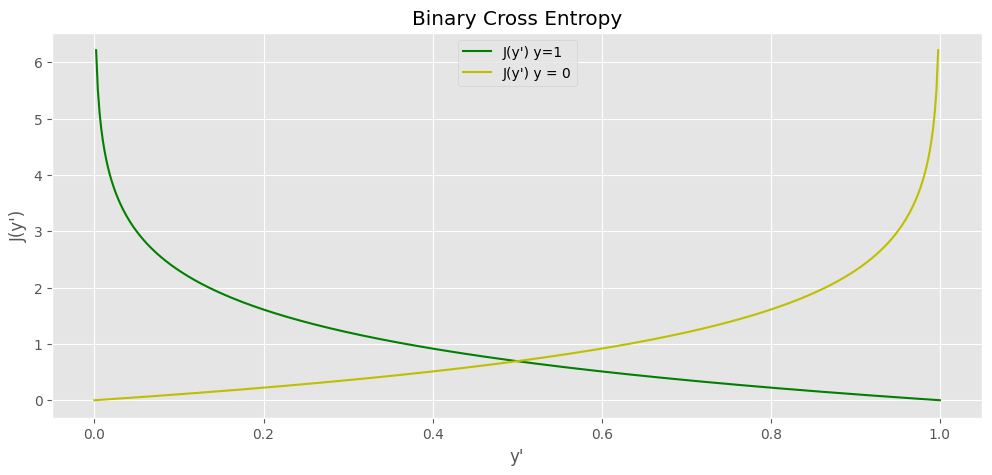

In [16]:
# Binary Cross Entropy graph
plt.rcParams["figure.figsize"] = (12, 5)
x = tf.linspace(0, 1, 500)
y1 = -tf.math.log(x)
y0 = -tf.math.log(1 - x)

plt.figure
plt.plot(x, y1, color="g", label="J(y') y=1 ")
plt.plot(x, y0, color="y", label="J(y') y = 0")
plt.xlabel("y'")
plt.ylabel("J(y')")
plt.legend(loc="upper center")
plt.title("Binary Cross Entropy")
plt.show()

In [17]:
def binary_cross_entropy(y_true, y_pred):
    loss = -((1.0 - y_true) * tf.math.log(1.0 - y_pred)) - (
        y_true * tf.math.log(y_pred)
    )
    return tf.reduce_mean(loss)

In [18]:
# Ground truth of a sample where the label is positive.
# Batch size is 1 and number of samples is 1.
# As the prediction is close to ground truth, loss should be close to 0.
y_truth = tf.Variable([1.0], shape=(1,))
y_pred = tf.Variable([0.95], shape=(1,))

print("Calc BCE loss: ", binary_cross_entropy(y_truth, y_pred))
print("Keras BSE loss: ", keras.losses.binary_crossentropy(y_truth, y_pred))

Calc BCE loss:  tf.Tensor(0.051293306, shape=(), dtype=float32)
Keras BSE loss:  tf.Tensor(0.051293306, shape=(), dtype=float32)


In [19]:
# Ground truth of a sample where the label is positive.
# As the prediction is wrong, i.e., far away from ground truth, loss should be much higher.
y_truth = tf.Variable([1.0], shape=(1,))
y_pred = tf.Variable([0.05], shape=(1,))

print("Calc BCE loss: ", binary_cross_entropy(y_truth, y_pred))
print("Keras BSE loss: ", keras.losses.binary_crossentropy(y_truth, y_pred))

Calc BCE loss:  tf.Tensor(2.9957323, shape=(), dtype=float32)
Keras BSE loss:  tf.Tensor(2.9957323, shape=(), dtype=float32)


In [20]:
# Ground truth of a sample where the label is negetive.
# As the prediction is close to ground truth, loss should be close to 0.
y_truth = tf.Variable([0.0], shape=(1,))
y_pred = tf.Variable([0.05], shape=(1,))

print("Calc BCE loss: ", binary_cross_entropy(y_truth, y_pred))
print("Keras BSE loss: ", keras.losses.binary_crossentropy(y_truth, y_pred))

Calc BCE loss:  tf.Tensor(0.051293306, shape=(), dtype=float32)
Keras BSE loss:  tf.Tensor(0.051293306, shape=(), dtype=float32)


#### Keras Implementation: Deep-dive into the `from_logits` parameter

There are two possible values that are accepted by the parameter:

 - from_logits=False: This indicates that the output of the neural network are already passed through an activation function. So, when calling the Keras loss function, it will not apply any action to the given prediction values.This is mainly the case we apply either the sigmoid or softmax activation to the last layer of the neural network.
 - from_logits=True: This indicates that the prediction values that we pass to the Keras loss functions are raw outputs from the neural network and the last layer of the neural network did not contain any activation function.

### Categorical Cross Entropy Loss

Categorical Cross Entropy loss is used in the case of multi-class classification problem. Here, the index of the positive class in the ground truth labels is always 1.
This is also called an **one-hot encoded vector**.

$$
Categorical Cross Entropy = - \sum^n_{i=1}{p_i * log(q_i)}
$$

where
- $p$ is the vector containing the ground truth labels
- $q$ is the vector containing the softmax probabilities containing the output predictions
- $n$ all the classes in the category

In [21]:
def categorical_cross_entropy(y_true: tf.Tensor, y_pred: tf.Tensor):
    loss = -(y_true * tf.math.log(y_pred))
    flattened_loss = tf.reshape(loss, -1)
    final_loss = [i for i in flattened_loss if i != 0]
    return tf.reduce_mean(final_loss)

In [23]:
# Batch size is 3 and number of samples is 1.
# As the prediction is close to ground truth, loss should be close to 0.
y_truth = tf.Variable([1.0, 0.0, 0.0], shape=(3,))
y_pred = tf.Variable([0.90, 0.05, 0.05], shape=(3,))

print("Calc CCE loss: ", categorical_cross_entropy(y_truth, y_pred))
print("Keras CSE loss: ", keras.losses.categorical_crossentropy(y_truth, y_pred))

Calc CCE loss:  tf.Tensor(0.105360545, shape=(), dtype=float32)
Keras CSE loss:  tf.Tensor(0.105360545, shape=(), dtype=float32)


In [ ]:
# Batch size is 3 and number of samples is 1.
# As the prediction is wrong, i.e., far away from ground truth, loss should be much higher.
y_truth = tf.Variable([1.0, 0.0, 0.0], shape=(3,))
y_pred = tf.Variable([0.025, 0.95, 0.025], shape=(3,))

print("Calc CCE loss: ", categorical_cross_entropy(y_truth, y_pred))
print("Keras CSE loss: ", keras.losses.categorical_crossentropy(y_truth, y_pred))

Calc CCE loss:  tf.Tensor(3.6888795, shape=(), dtype=float32)
Keras CSE loss:  tf.Tensor(3.6888793, shape=(), dtype=float32)


In [26]:
# Batch size is 3 and number of samples is 1.
# As the prediction is correct but the confidence is just a little higher than the other classes, loss will be slightly higher.
y_truth = tf.Variable([0.0, 0.0, 1.0], shape=(3,))
y_pred = tf.Variable([0.3, 0.3, 0.4], shape=(3,))

print("Calc CCE loss: ", categorical_cross_entropy(y_truth, y_pred))
print("Keras CSE loss: ", keras.losses.categorical_crossentropy(y_truth, y_pred))

Calc CCE loss:  tf.Tensor(0.9162907, shape=(), dtype=float32)
Keras CSE loss:  tf.Tensor(0.9162907, shape=(), dtype=float32)


In [27]:
# Batch size is 3 and number of samples is 1.
# The confidence of each class is the same.
y_truth = tf.Variable([0.0, 1.0, 0.0], shape=(3,))
y_pred = tf.Variable([0.33, 0.33, 0.33], shape=(3,))

print("Calc CCE loss: ", categorical_cross_entropy(y_truth, y_pred))
print("Keras CSE loss: ", keras.losses.categorical_crossentropy(y_truth, y_pred))

Calc CCE loss:  tf.Tensor(1.1086626, shape=(), dtype=float32)
Keras CSE loss:  tf.Tensor(1.0986123, shape=(), dtype=float32)


For the loss to be as low as possible, the predicted value for the correct class should be as high, and the predicted value for the other classes should be as low as possible.

In [29]:
# `from_logits` set to True
y_truth = tf.Variable([1.0, 0.0, 0.0], shape=(3,))
y_pred = tf.Variable([12.0, 5.0, 7.0], shape=(3,))
print(
    "from_logits=True, CSE loss: ",
    keras.losses.categorical_crossentropy(y_truth, y_pred, from_logits=True),
)

# `from_logits` set to False
y_truth = tf.Variable([1.0, 0.0, 0.0], shape=(3,))
y_pred = tf.Variable([0.99240828, 0.00090495922, 0.0066867946], shape=(3,))
print(
    "from_logits=False, Keras CSE loss: ",
    keras.losses.categorical_crossentropy(y_truth, y_pred, from_logits=False),
)

from_logits=True, CSE loss:  tf.Tensor(0.007620668, shape=(), dtype=float32)
from_logits=False, Keras CSE loss:  tf.Tensor(0.007620688, shape=(), dtype=float32)


### Sparce Categorical Cross Entropy

For Sparse Categorical Cross Entropy loss, the format of the ground truth labels change a bit. Unlike CCE, here, the ground truth vector directly contains the class number. So, if we have three classes in total (0, 1, and 2) and two data points (samples), then the ground truth vector, where classes 1 and 2 are the true labels will be: $[1, 2]$

Sparse Categorical Cross Entropy is generally used when the samples are mutually exclusive. This means that each sample can belong to one class. Therefore, the class it belongs to can be represented using just a single integer.

#### Benefits over Categorical Cross Entropy

When there are hundreds of classes, one-hot encoding takes more time and memory as all the classes need to be encoded. But in the case of Sparse Categorical, only a single vector where each element specifies the class number for sample is present. Thus, conserving time and memory during calculation of loss.

In [44]:
def sparce_categorical_cross_entropy(y_true, y_pred):
    numSamples = len(y_true)
    loss = []
    for i in range(numSamples):
        y_true_sample = y_true[i]
        y_pred_sample = y_pred[i]

        loss.append(-(tf.math.log(y_pred_sample[y_true_sample])))

    return tf.reduce_mean(loss)

In [45]:
# Batch size is 3 and number of samples is 1.
# As the prediction is close to ground truth, loss should be close to 0.
y_truth = tf.Variable([0], shape=(1,))
y_pred = tf.Variable([[0.90, 0.05, 0.05]], shape=(1, 3))

print(
    "Calc SCCE loss: ",
    sparce_categorical_cross_entropy(y_truth.numpy(), y_pred.numpy()),
)
print(
    "Keras SCSE loss: ", keras.losses.sparse_categorical_crossentropy(y_truth, y_pred)
)

Calc SCCE loss:  tf.Tensor(0.105360545, shape=(), dtype=float32)
Keras SCSE loss:  tf.Tensor([0.10536056], shape=(1,), dtype=float32)


In [46]:
# Batch size is 3 and number of samples is 1.
# As the prediction is close to ground truth, loss should be close to 0.
y_truth = tf.Variable([0], shape=(1,))
y_pred = tf.Variable([[0.025, 0.95, 0.025]], shape=(1, 3))

print(
    "Calc SCCE loss: ",
    sparce_categorical_cross_entropy(y_truth.numpy(), y_pred.numpy()),
)
print(
    "Keras SCSE loss: ", keras.losses.sparse_categorical_crossentropy(y_truth, y_pred)
)

Calc SCCE loss:  tf.Tensor(3.6888795, shape=(), dtype=float32)
Keras SCSE loss:  tf.Tensor([3.6888795], shape=(1,), dtype=float32)


In [48]:
# Batch size is 3 and number of samples is 1.
# As the prediction is correct but the confidence is just a little higher than the other classes, loss will be slightly higher.
y_truth = tf.Variable([2], shape=(1,))
y_pred = tf.Variable([[0.3, 0.3, 0.4]], shape=(1, 3))

print(
    "Calc SCCE loss: ",
    sparce_categorical_cross_entropy(y_truth.numpy(), y_pred.numpy()),
)
print(
    "Keras SCSE loss: ", keras.losses.sparse_categorical_crossentropy(y_truth, y_pred)
)

Calc SCCE loss:  tf.Tensor(0.9162907, shape=(), dtype=float32)
Keras SCSE loss:  tf.Tensor([0.91629076], shape=(1,), dtype=float32)


In [49]:
# Batch size is 3 and number of samples is 1.
# The confidence of each class is the same.
y_truth = tf.Variable([1], shape=(1,))
y_pred = tf.Variable([[0.33, 0.33, 0.33]], shape=(1, 3))

print(
    "Calc SCCE loss: ",
    sparce_categorical_cross_entropy(y_truth.numpy(), y_pred.numpy()),
)
print(
    "Keras SCSE loss: ", keras.losses.sparse_categorical_crossentropy(y_truth, y_pred)
)

Calc SCCE loss:  tf.Tensor(1.1086626, shape=(), dtype=float32)
Keras SCSE loss:  tf.Tensor([1.0986123], shape=(1,), dtype=float32)
